# Hybrid Enhanced Stacked Ensemble for Network Intrusion Detection

**Integrating LightGBM + Random Subspace Bagging with Logistic Regression Meta-Learner**

Comprehensive workflow: data loading, preprocessing, training, evaluation, and **real-time NIDS simulation**.

In [2]:
# ============================
# 1. IMPORTS & CONFIG
# ============================
import sys, os, glob, gc, warnings, time, random
from datetime import datetime
from collections import deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    log_loss, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc as sk_auc
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

CSV_FOLDER     = './MachineLearningCVE'
LABEL_COL      = 'Label'
N_FOLDS        = 10
TEST_SIZE      = 0.3
RANDOM_STATE   = 42
OUTPUT_DIR     = '.'
os.makedirs(OUTPUT_DIR, exist_ok=True)

import sklearn
print(f'Scikit-learn : {sklearn.__version__}')
print(f'LightGBM     : {lgb.__version__}')
print(f'Pandas       : {pd.__version__}')

Scikit-learn : 1.8.0
LightGBM     : 4.6.0
Pandas       : 3.0.2


In [3]:
# ============================
# 2. LOAD DATA
# ============================
csv_files = sorted(glob.glob(os.path.join(CSV_FOLDER, '*.csv')))
if not csv_files:
    raise FileNotFoundError(f'No CSV files in {CSV_FOLDER}')
dfs = []
for f in csv_files:
    print(f'  Loading {os.path.basename(f)}')
    dfs.append(pd.read_csv(f, low_memory=False))
df = pd.concat(dfs, ignore_index=True)
print(f'Total rows: {len(df):,}')
del dfs; gc.collect()

# ============================
# 3. PREPROCESSING
# ============================
df.columns = df.columns.str.strip()
drop_cols = [c for c in ['Flow ID','Source IP','Destination IP','Timestamp',
                          'Src IP','Dst IP','src_ip','dst_ip'] if c in df.columns]
if drop_cols:
    df.drop(columns=drop_cols, inplace=True)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(axis=1, thresh=len(df)*0.5, inplace=True)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if num_cols:
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Dedup removed {before - len(df):,} rows')
print(f'Shape: {df.shape}')

  Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Loading Friday-WorkingHours-Morning.pcap_ISCX.csv
  Loading Monday-WorkingHours.pcap_ISCX.csv
  Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Loading Tuesday-WorkingHours.pcap_ISCX.csv
  Loading Wednesday-workingHours.pcap_ISCX.csv
Total rows: 2,830,743
Dedup removed 308,381 rows
Shape: (2522362, 79)


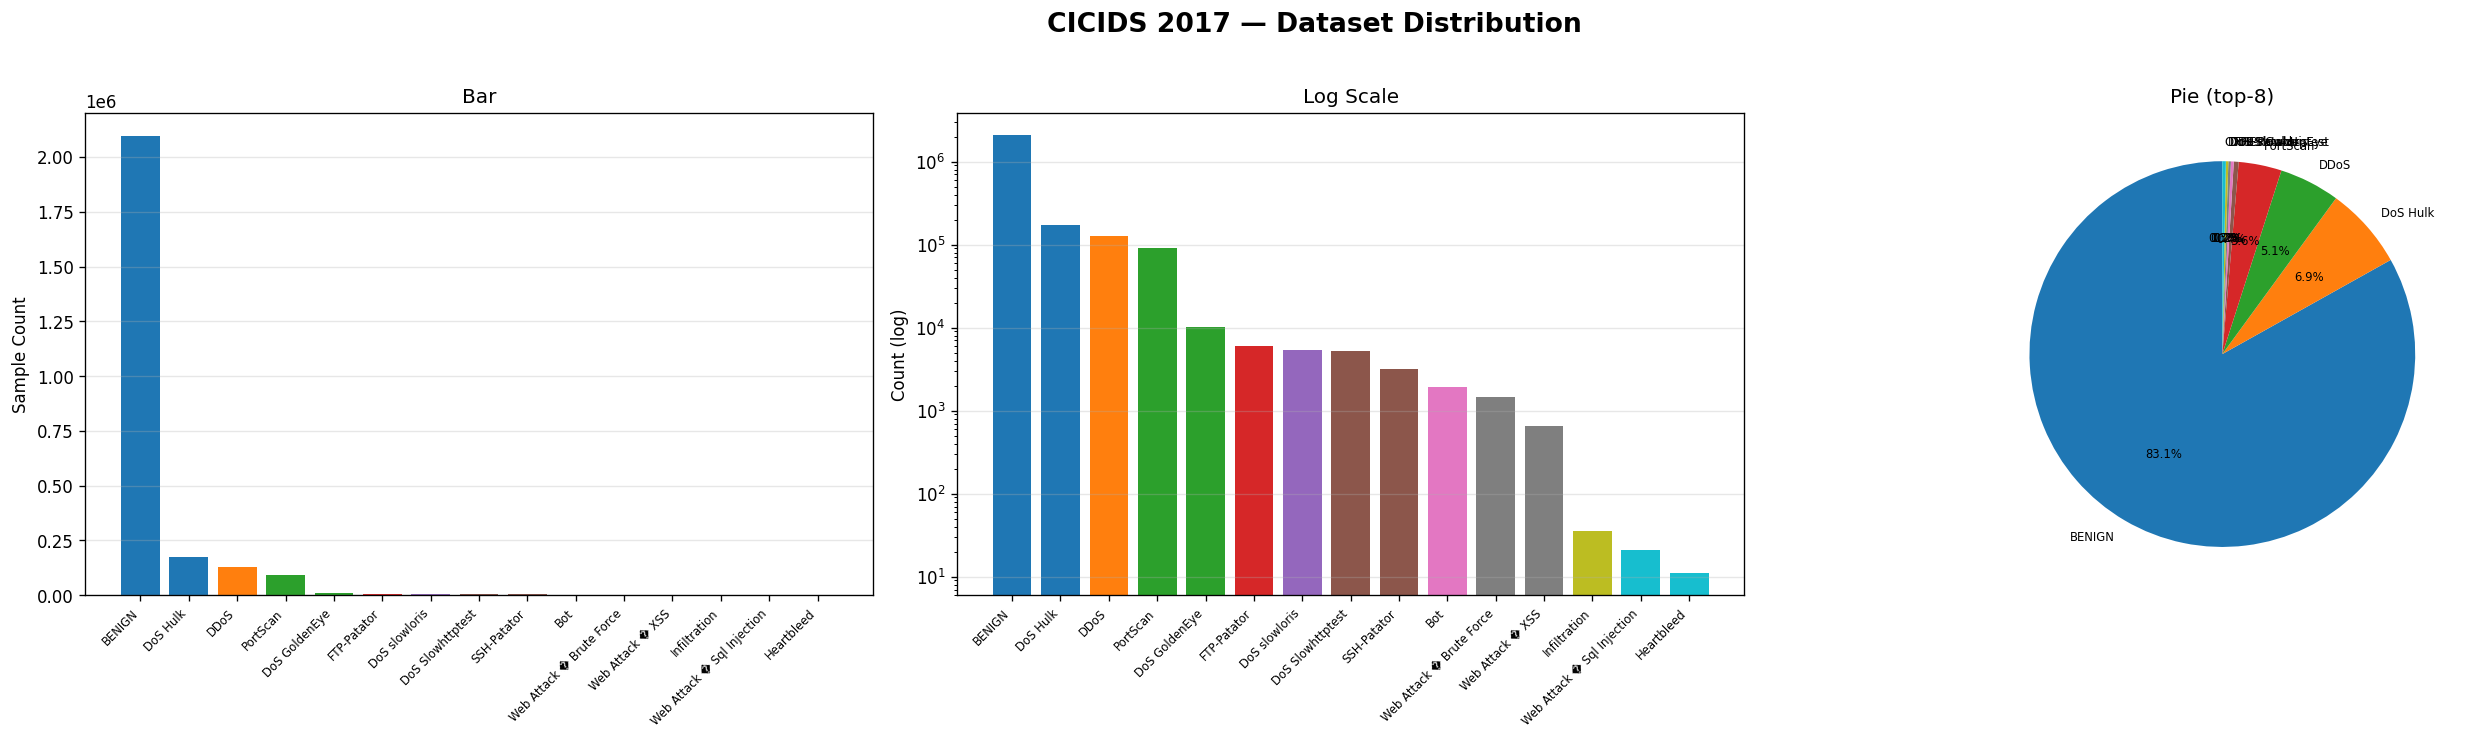

Saved: dataset_distribution.png


In [4]:
# ============================
# 4. DATASET DISTRIBUTION
# ============================
class_counts = df[LABEL_COL].value_counts()
class_names_raw = class_counts.index.tolist()
n_classes_raw = len(class_names_raw)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('CICIDS 2017 — Dataset Distribution', fontsize=16, fontweight='bold', y=1.02)
colors = plt.cm.tab10(np.linspace(0, 1, n_classes_raw))
axes[0].bar(range(n_classes_raw), class_counts.values, color=colors)
axes[0].set_xticks(range(n_classes_raw)); axes[0].set_xticklabels(class_names_raw, rotation=45, ha='right', fontsize=7)
axes[0].set_ylabel('Sample Count'); axes[0].set_title('Bar'); axes[0].grid(axis='y', alpha=0.3)
axes[1].bar(range(n_classes_raw), class_counts.values, color=colors)
axes[1].set_xticks(range(n_classes_raw)); axes[1].set_xticklabels(class_names_raw, rotation=45, ha='right', fontsize=7)
axes[1].set_yscale('log'); axes[1].set_ylabel('Count (log)'); axes[1].set_title('Log Scale'); axes[1].grid(axis='y', alpha=0.3)
top_n = min(8, n_classes_raw)
pie_data = class_counts if n_classes_raw <= top_n else pd.concat([class_counts.head(top_n), pd.Series({'OTHER': class_counts.iloc[top_n:].sum()})])
axes[2].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
            colors=plt.cm.tab10(np.linspace(0,1,len(pie_data))), startangle=90, textprops={'fontsize':7})
axes[2].set_title(f'Pie (top-{top_n})', fontsize=12)
plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dataset_distribution.png')

In [5]:
# ============================
# 5. ENCODING & SPLIT
# ============================
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df[LABEL_COL].astype(str))
class_names = le.classes_; n_classes = len(class_names)
print(f'Classes: {n_classes}')
for i, n in enumerate(class_names): print(f'  {i:2d}: {n}')

X = df.drop(columns=[LABEL_COL, 'label_enc']).select_dtypes(include=[np.number])
y = df['label_enc']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
scaler = MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
del df; gc.collect()

Classes: 15
   0: BENIGN
   1: Bot
   2: DDoS
   3: DoS GoldenEye
   4: DoS Hulk
   5: DoS Slowhttptest
   6: DoS slowloris
   7: FTP-Patator
   8: Heartbleed
   9: Infiltration
  10: PortScan
  11: SSH-Patator
  12: Web Attack � Brute Force
  13: Web Attack � Sql Injection
  14: Web Attack � XSS
Train: (1765653, 78), Test: (756709, 78)


773

In [6]:

# 6. BASE LEARNERS

lgbm_model = lgb.LGBMClassifier(
    objective='multiclass', metric='multi_logloss', num_class=n_classes,
    n_estimators=100, learning_rate=0.05, max_depth=8, num_leaves=63,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1, class_weight='balanced',
    device='cpu', random_state=RANDOM_STATE, n_jobs=2, verbose=-1)
print('  LightGBM OK')

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(criterion='gini', max_depth=10, min_samples_split=20, min_samples_leaf=10, random_state=RANDOM_STATE),
    n_estimators=100, max_samples=0.8, max_features=0.5,
    bootstrap=True, n_jobs=2, random_state=RANDOM_STATE)
print('  Bagging+DT (Random Subspace) OK')

  LightGBM OK
  Bagging+DT (Random Subspace) OK


In [ ]:
# ============================
# 7. CROSS-VALIDATION
# ============================
print(f'Running {N_FOLDS}-Fold CV...\n')
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof_lgbm = np.zeros((len(X_train), n_classes))
oof_bagging = np.zeros((len(X_train), n_classes))
test_lgbm_accum = np.zeros((len(X_test), n_classes))
test_bagging_accum = np.zeros((len(X_test), n_classes))
fold_loss_curves = []
Xa, ya = X_train.values, y_train.values
Xta = X_test.values

for fold, (tr_idx, val_idx) in enumerate(skf.split(Xa, ya), 1):
    print(f'  Fold {fold}/{N_FOLDS}', end='')
    Xtr, Xval = Xa[tr_idx], Xa[val_idx]; ytr, yval = ya[tr_idx], ya[val_idx]
    evals = {}
    lgbm_model.fit(Xtr, ytr, eval_set=[(Xtr, ytr), (Xval, yval)], eval_names=['train','eval'],
                   callbacks=[lgb.record_evaluation(evals), lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    oof_lgbm[val_idx] = lgbm_model.predict_proba(Xval)
    test_lgbm_accum += lgbm_model.predict_proba(Xta)
    fold_loss_curves.append({'fold':fold,'train':evals['train']['multi_logloss'],'eval':evals['eval']['multi_logloss'],'best':lgbm_model.best_iteration_})
    print(' | LGBM OK', end='')
    sw = compute_sample_weight(class_weight='balanced', y=ytr)
    bagging_model.fit(Xtr, ytr, sample_weight=sw)
    oof_bagging[val_idx] = bagging_model.predict_proba(Xval)
    test_bagging_accum += bagging_model.predict_proba(Xta)
    print(' | Bagging OK')
    gc.collect()
test_lgbm_avg = test_lgbm_accum / N_FOLDS
test_bagging_avg = test_bagging_accum / N_FOLDS
print(f'\nOOF done. Shapes: {oof_lgbm.shape}, {oof_bagging.shape}')

Running 10-Fold CV...

  Fold 1/10 | LGBM OK | Bagging OK
  Fold 2/10 | LGBM OK | Bagging OK
  Fold 3/10

In [ ]:
# ============================
# 8. LOSS CURVES
# ============================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LightGBM Loss Curves — CV Folds', fontsize=15, fontweight='bold')
colors_fold = plt.cm.Set1(np.linspace(0, 1, N_FOLDS))
for i, fc in enumerate(fold_loss_curves):
    axes[0].plot(fc['train'], color=colors_fold[i], alpha=0.8, label=f"Fold {fc['fold']}")
    axes[1].plot(fc['eval'], color=colors_fold[i], alpha=0.8, label=f"Fold {fc['fold']} (best={fc['best']})")
    best = fc['best'] - 1
    if best < len(fc['eval']):
        axes[1].scatter(best, fc['eval'][best], color=colors_fold[i], s=40, zorder=5, edgecolors='black', linewidths=0.5)
axes[0].set_xlabel('Round'); axes[0].set_ylabel('Multi Log Loss'); axes[0].set_title('Training Loss'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('Round'); axes[1].set_ylabel('Multi Log Loss'); axes[1].set_title('Validation Loss'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved: loss_curves.png')

In [ ]:
# ============================
# 9. META-LEARNER
# ============================
M_train = np.hstack([oof_lgbm, oof_bagging])
M_test  = np.hstack([test_lgbm_avg, test_bagging_avg])
print(f'Meta features: Train {M_train.shape}, Test {M_test.shape}')
meta = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced', solver='lbfgs', n_jobs=-1)
meta.fit(M_train, ya)
print('Meta-learner trained OK')

In [ ]:
# ============================
# 10. EVALUATION
# ============================
y_pred = meta.predict(M_test)
y_prob = meta.predict_proba(M_test)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
ll = log_loss(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
print('STACKED ENSEMBLE METRICS')
print(f'  Accuracy : {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}')
print(f'  F1: {f1:.4f} | AUC-ROC: {auc_score:.4f} | LogLoss: {ll:.4f}')

In [ ]:
# ============================
# 11. METRICS BAR CHART
# ============================
names = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']
vals  = [acc, prec, rec, f1, auc_score]
colors = ['#2ecc71','#3498db','#e74c3c','#9b59b6','#f39c12']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, vals, color=colors, width=0.6, edgecolor='black', linewidth=0.5)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.15); ax.set_title('Performance Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score'); ax.axhline(y=1.0, color='gray', ls='--', alpha=0.5); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('performance_metrics.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved: performance_metrics.png')

In [ ]:
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

In [ ]:
# ============================
# 12. PER-CLASS METRICS PLOT
# ============================
prec_p = precision_score(y_test, y_pred, average=None, zero_division=0)
rec_p  = recall_score(y_test, y_pred, average=None, zero_division=0)
f1_p   = f1_score(y_test, y_pred, average=None, zero_division=0)
x = np.arange(n_classes); w = 0.25
fig, ax = plt.subplots(figsize=(max(12, n_classes*0.9), 7))
ax.bar(x-w, prec_p, w, label='Precision', color='#3498db', edgecolor='black', lw=0.3)
ax.bar(x, rec_p, w, label='Recall', color='#2ecc71', edgecolor='black', lw=0.3)
ax.bar(x+w, f1_p, w, label='F1-Score', color='#e74c3c', edgecolor='black', lw=0.3)
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Score'); ax.set_title('Per-Class Precision, Recall & F1', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.15); ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3); ax.axhline(y=1.0, color='gray', ls='--', alpha=0.3)
plt.tight_layout(); plt.savefig('classification_report_graph.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved: classification_report_graph.png')

In [ ]:
# ============================
# 13. CONFUSION MATRIX
# ============================
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(max(10,n_classes), max(8,n_classes-1)))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45, values_format='d')
ax.set_title('Confusion Matrix - Counts', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('confusion_matrix_counts.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved: confusion_matrix_counts.png')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(max(10,n_classes), max(8,n_classes-1)))
ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45, values_format='.2f')
ax.set_title('Confusion Matrix - Normalized', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('confusion_matrix_normalized.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved: confusion_matrix_normalized.png')

In [ ]:
# ============================
# 14. ROC CURVES
# ============================
y_bin = label_binarize(y_test, classes=list(range(n_classes)))
fig, ax = plt.subplots(figsize=(12, 8))
colors_roc = plt.cm.tab20(np.linspace(0, 1, n_classes))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc_i = sk_auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=1.5, color=colors_roc[i], label=f'{class_names[i]} (AUC={roc_auc_i:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.set_title('ROC Curves - One-vs-Rest', fontsize=14, fontweight='bold')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(loc='lower right', fontsize=7, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved: roc_curves.png')

In [ ]:
print('\nPer-class AUC-ROC:')
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    print(f'  {class_names[i]:35s}: {sk_auc(fpr, tpr):.4f}')